## Notebook 13 - Centrality distribution: entropy and effective number of players
Núria Pascual Salas

**Content:** Describes how player influence is distributed within each team, using the
whole centrality distribution rather than just top-k or Gini summaries. Computes two
measures on the normalised centrality $p_i$: the normalised Shannon entropy
$S = -\sum_i p_i \ln p_i / \ln N$ (how evenly influence is spread: 0 means one dominant
player, 1 means perfectly uniform), and the effective number of players
$N_{\mathrm{eff}} = 1 / \sum_i p_i^2$ (how many players effectively carry the play).
Both metrics are derived from the centrality distribution alone and are later related to final league points and the fragility measure from Chapter 4. Centrality is calculated on the aggregated season network for each team, as in Notebook 03.

**Inputs:**
- sf_per_team_correlations.csv (total_points, mean_sf, from notebook 01)
- fragility_per_team.csv (fragility, from notebook 05)

**Outputs:**
- outputs/csv/entropy_neff_per_team.csv
- outputs/figures/entropy_neff_vs_points.png
- outputs/figures/entropy_neff_vs_fragility.png

**Used in:** Chapter 4, Sections 4.2-4.3 (influence distribution).

In [1]:
from utils import *
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.stats import pearsonr, spearmanr

FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

### 1. Season-aggregated network and global metrics per team

In [2]:
consolidated_networks = {}
for team_id, team_name in all_teams.items():
    G_team, n = build_consolidated_network(team_id, team_name, zip_path, folder_laliga)
    consolidated_networks[team_name] = {'graph': G_team, 'n_matches': n, 'team_id': team_id}
    print(f"{team_name:18s} | {n} matches | {G_team.number_of_nodes():3d} players | "
          f"{G_team.number_of_edges():4d} edges")

Deportivo Alavés   | 38 matches |  29 players |  498 edges
Granada            | 38 matches |  40 players |  769 edges
Barcelona          | 38 matches |  29 players |  591 edges
Almería            | 38 matches |  35 players |  767 edges
Sevilla            | 38 matches |  35 players |  784 edges
Cádiz              | 38 matches |  33 players |  664 edges
Girona             | 38 matches |  25 players |  398 edges
Athletic Club      | 38 matches |  27 players |  561 edges
Real Sociedad      | 38 matches |  31 players |  640 edges
Mallorca           | 38 matches |  25 players |  500 edges
Real Betis         | 38 matches |  35 players |  824 edges
Atlético Madrid    | 38 matches |  27 players |  502 edges
Villarreal         | 38 matches |  32 players |  727 edges
Celta Vigo         | 38 matches |  31 players |  672 edges
Valencia           | 38 matches |  30 players |  542 edges
Las Palmas         | 38 matches |  29 players |  596 edges
Osasuna            | 38 matches |  29 players |  511 edg

### 2. Compute centrality distribution descriptors per team

In [3]:
rows = []
for team_name, data in consolidated_networks.items():
    G = data['graph']
    if G.number_of_nodes() == 0:
        continue

    pr = nx.pagerank(G, weight='weight')
    bt = nx.betweenness_centrality(G, weight='weight')   # NB: weight = pass count

    d_pr = distribution_descriptors(list(pr.values()))
    d_bt = distribution_descriptors(list(bt.values()))

    rows.append({
        'team':            team_name,
        'team_id':         data['team_id'],
        'n_nodes':         G.number_of_nodes(),
        # PageRank-based descriptors (primary)
        'S_pr':            d_pr['S_norm'],
        'Neff_pr':         d_pr['N_eff'],
        'Neff_frac_pr':    d_pr['N_eff_frac'],
        'gini_pr':         d_pr['gini'],
        # Betweenness-based descriptors (robustness check)
        'S_bt':            d_bt['S_norm'],
        'Neff_bt':         d_bt['N_eff'],
        'gini_bt':         d_bt['gini'],
    })

df_entropy = pd.DataFrame(rows)
df_entropy = df_entropy.sort_values('Neff_pr', ascending=False).reset_index(drop=True)
print(df_entropy.round(4).to_string(index=False))

            team  team_id  n_nodes   S_pr  Neff_pr  Neff_frac_pr  gini_pr   S_bt  Neff_bt  gini_bt
      Real Betis      218       35 0.9371  24.1752        0.6907   0.3690 0.8810  18.2683   0.4969
         Almería      403       35 0.9302  23.4758        0.6707   0.3924 0.8714  15.7234   0.5077
         Sevilla      213       35 0.9233  22.8330        0.6524   0.4092 0.8672  16.0264   0.5250
      Villarreal      222       32 0.9427  22.7120        0.7097   0.3499 0.8240  12.9596   0.5893
           Cádiz      552       33 0.9211  21.1417        0.6407   0.4114 0.8869  17.1194   0.4819
         Granada     1049       40 0.8910  20.8677        0.5217   0.4940 0.9445  27.4225   0.3466
          Getafe      216       32 0.9187  20.4134        0.6379   0.4162 0.8547  14.9007   0.5338
         Osasuna      422       29 0.9278  20.3475        0.7016   0.3721 0.7926   8.0955   0.5973
   Real Sociedad      210       31 0.9230  20.3418        0.6562   0.4042 0.8592  14.6710   0.5359
   Athleti

### 3. Merge with points and fragility

In [4]:
df_style = pd.read_csv(f'{CSV_DIR}/sf_per_team_correlations.csv')
keep = [c for c in ['team', 'total_points', 'mean_sf', 'r_sf_points'] if c in df_style.columns]
df = df_entropy.merge(df_style[keep], on='team', how='left')

frag_path = f'{CSV_DIR}/fragility_per_team.csv'
if os.path.exists(frag_path):
    df_frag = pd.read_csv(frag_path)
    frag_col = next((c for c in df_frag.columns if 'fragil' in c.lower()), None)
    if frag_col:
        df = df.merge(df_frag[['team', frag_col]].rename(columns={frag_col: 'fragility'}),
                      on='team', how='left')
        print(f"Merged fragility from column '{frag_col}'.")
    else:
        print("fragility_per_team.csv found but no fragility-like column detected.")
else:
    print("No fragility file found - fragility section will be skipped.")

print(df.round(4).to_string(index=False))
df.to_csv(f'{CSV_DIR}/entropy_neff_per_team.csv', index=False)

Merged fragility from column 'fragility'.
            team  team_id  n_nodes   S_pr  Neff_pr  Neff_frac_pr  gini_pr   S_bt  Neff_bt  gini_bt  total_points  mean_sf  r_sf_points  fragility
      Real Betis      218       35 0.9371  24.1752        0.6907   0.3690 0.8810  18.2683   0.4969            60   0.1786      -0.1481     0.3295
         Almería      403       35 0.9302  23.4758        0.6707   0.3924 0.8714  15.7234   0.5077            21   0.2027       0.1196     0.3471
         Sevilla      213       35 0.9233  22.8330        0.6524   0.4092 0.8672  16.0264   0.5250            42   0.1836       0.3292     0.2971
      Villarreal      222       32 0.9427  22.7120        0.7097   0.3499 0.8240  12.9596   0.5893            51   0.1632       0.1896     0.3082
           Cádiz      552       33 0.9211  21.1417        0.6407   0.4114 0.8869  17.1194   0.4819            32   0.2413       0.1186     0.3322
         Granada     1049       40 0.8910  20.8677        0.5217   0.4940 0.9445  

### 4. Relationship with final league performance ($n=20$)

In [5]:
def corr_report(df, xcol, ycol):
    sub = df[[xcol, ycol]].dropna()
    if len(sub) < 3:
        return None
    r, p   = pearsonr(sub[xcol], sub[ycol])
    rs, ps = spearmanr(sub[xcol], sub[ycol])
    return {'x': xcol, 'y': ycol, 'n': len(sub),
            'pearson_r': round(r, 3),  'pearson_p': round(p, 4),
            'spearman_r': round(rs, 3), 'spearman_p': round(ps, 4)}


targets = [c for c in ['total_points', 'fragility'] if c in df.columns]
measures = ['S_pr', 'Neff_pr', 'Neff_frac_pr', 'gini_pr']

corr_rows = [corr_report(df, m, t) for t in targets for m in measures]
corr_rows = [r for r in corr_rows if r is not None]
df_corr = pd.DataFrame(corr_rows)
print(df_corr.to_string(index=False))

           x            y  n  pearson_r  pearson_p  spearman_r  spearman_p
        S_pr total_points 20      0.257     0.2744       0.236      0.3174
     Neff_pr total_points 20     -0.361     0.1176      -0.337      0.1466
Neff_frac_pr total_points 20      0.354     0.1254       0.315      0.1764
     gini_pr total_points 20     -0.328     0.1586      -0.291      0.2125
        S_pr    fragility 20     -0.690     0.0008      -0.681      0.0009
     Neff_pr    fragility 20     -0.025     0.9169       0.059      0.8060
Neff_frac_pr    fragility 20     -0.625     0.0032      -0.577      0.0077
     gini_pr    fragility 20      0.674     0.0011       0.632      0.0028


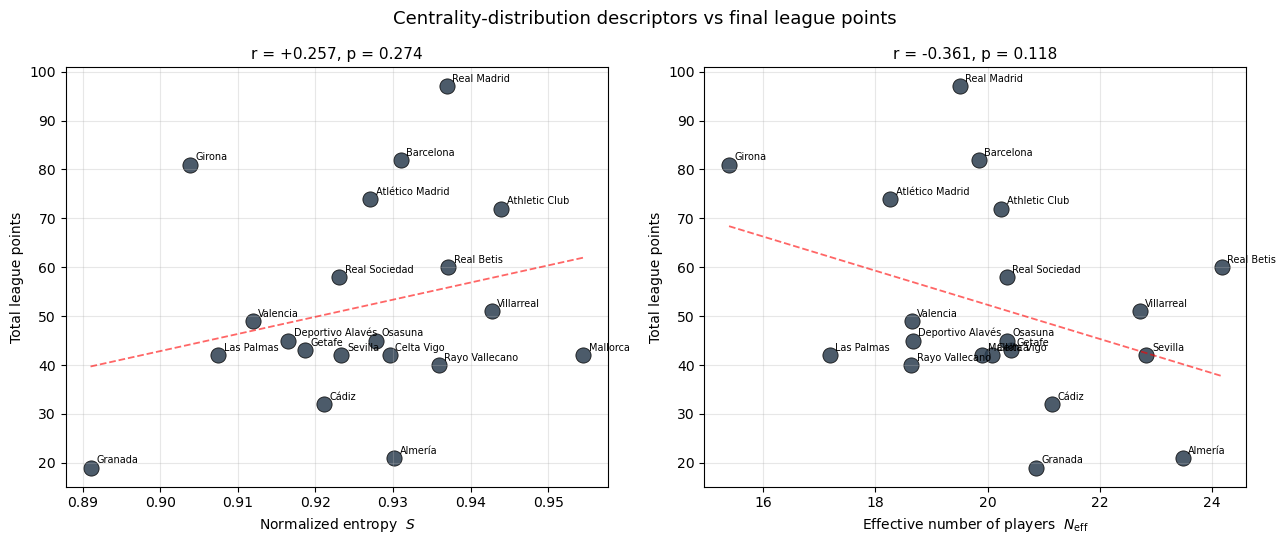

In [6]:
if 'total_points' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    for ax, (measure, label) in zip(
            axes,
            [('S_pr', 'Normalized entropy  $S$'),
             ('Neff_pr', 'Effective number of players  $N_{\\mathrm{eff}}$')]):
        sub = df[[measure, 'total_points', 'team']].dropna()
        ax.scatter(sub[measure], sub['total_points'], s=120, alpha=0.85,
                   color='#2c3e50', edgecolors='black', linewidths=0.6)
        for _, row in sub.iterrows():
            ax.annotate(row['team'], (row[measure], row['total_points']),
                        fontsize=7, textcoords='offset points', xytext=(4, 3))
        m, b = np.polyfit(sub[measure], sub['total_points'], 1)
        xline = np.linspace(sub[measure].min(), sub[measure].max(), 100)
        ax.plot(xline, m * xline + b, 'r--', alpha=0.6, linewidth=1.3)
        r, p = pearsonr(sub[measure], sub['total_points'])
        ax.set_xlabel(label, fontsize=10)
        ax.set_ylabel('Total league points', fontsize=10)
        ax.set_title(f'r = {r:+.3f}, p = {p:.3f}', fontsize=11)
        ax.grid(alpha=0.3)
    plt.suptitle('Centrality-distribution descriptors vs final league points', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/entropy_neff_vs_points.png', dpi=130, bbox_inches='tight')
    plt.show()

### 5. Relationship with structural fragility

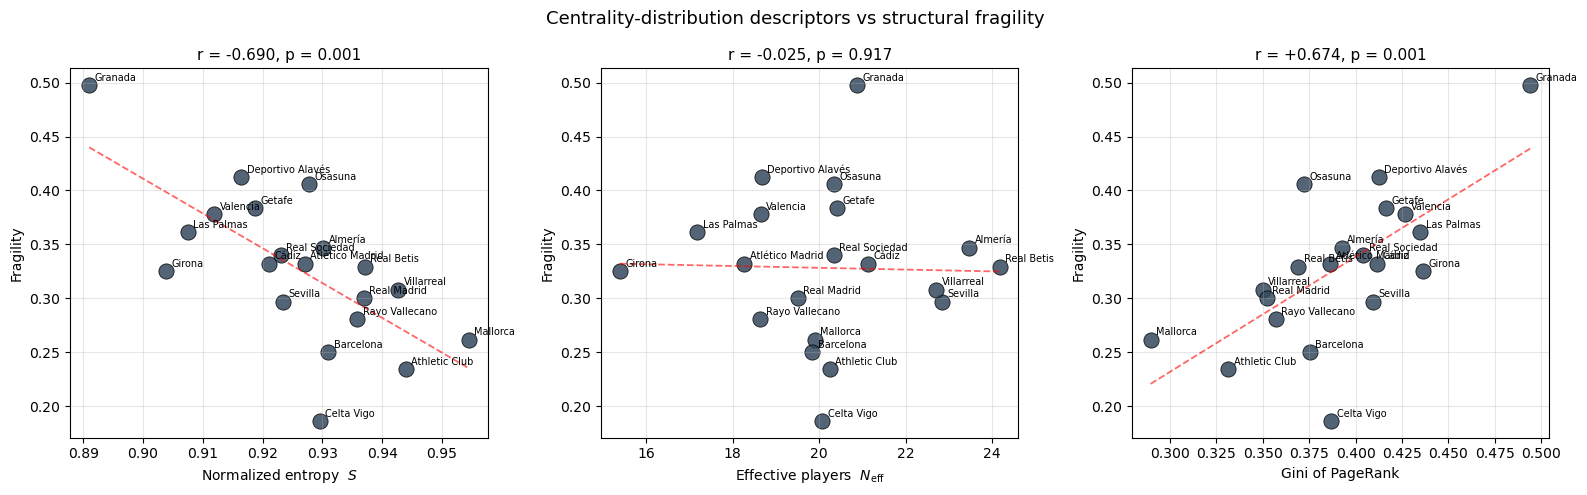

In [7]:
if 'fragility' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    specs = [('S_pr',    'Normalized entropy  $S$'),
             ('Neff_pr', 'Effective players  $N_{\\mathrm{eff}}$'),
             ('gini_pr', 'Gini of PageRank')]
    for ax, (measure, label) in zip(axes, specs):
        sub = df[[measure, 'fragility', 'team']].dropna()
        ax.scatter(sub[measure], sub['fragility'], s=120, alpha=0.85,
                   color='#34495e', edgecolors='black', linewidths=0.6)
        for _, row in sub.iterrows():
            ax.annotate(row['team'], (row[measure], row['fragility']),
                        fontsize=7, textcoords='offset points', xytext=(4, 3))
        m, b = np.polyfit(sub[measure], sub['fragility'], 1)
        xline = np.linspace(sub[measure].min(), sub[measure].max(), 100)
        ax.plot(xline, m * xline + b, 'r--', alpha=0.6, linewidth=1.3)
        r, p = pearsonr(sub[measure], sub['fragility'])
        ax.set_xlabel(label, fontsize=10)
        ax.set_ylabel('Fragility', fontsize=10)
        ax.set_title(f'r = {r:+.3f}, p = {p:.3f}', fontsize=11)
        ax.grid(alpha=0.3)
    plt.suptitle('Centrality-distribution descriptors vs structural fragility', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/entropy_neff_vs_fragility.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print("Skipped: no fragility column merged.")

### 6. Diagnostics
#### Size confound: how much does plantilla size N drive each measure? 


In [8]:
print("Contamination by plantilla size N (n_nodes):")
for m in ['Neff_pr', 'Neff_frac_pr', 'S_pr', 'gini_pr']:
    sub = df[['n_nodes', m]].dropna()
    r, p = pearsonr(sub['n_nodes'], sub[m])
    flag = '  <-- strongly size-driven' if abs(r) > 0.6 else ''
    print(f"  {m:14s} vs N:  r = {r:+.3f}, p = {p:.4f}{flag}")
print()
print("Reading: raw Neff tracks N closely and should NOT be compared across teams;")
print("S and Neff_frac are the size-comparable measures.")

Contamination by plantilla size N (n_nodes):
  Neff_pr        vs N:  r = +0.697, p = 0.0006  <-- strongly size-driven
  Neff_frac_pr   vs N:  r = -0.558, p = 0.0105
  S_pr           vs N:  r = -0.379, p = 0.0995
  gini_pr        vs N:  r = +0.537, p = 0.0147

Reading: raw Neff tracks N closely and should NOT be compared across teams;
S and Neff_frac are the size-comparable measures.


#### Equivalence of the concentration measures (redundancy check)


In [9]:
conc_measures = ['S_pr', 'gini_pr', 'Neff_frac_pr']
corr_mat = df[conc_measures].corr(method='pearson').round(3)
print("Pearson correlation matrix among concentration measures:")
print(corr_mat.to_string())
print()
r_sg, p_sg = pearsonr(df['S_pr'].dropna(), df.loc[df['S_pr'].notna(), 'gini_pr'])
print(f"S vs Gini: r = {r_sg:+.3f}, p = {p_sg:.2e}  ->  R^2 = {r_sg**2:.3f}")
print("If |r| ~ 1, entropy and Gini are the SAME property; entropy is preferred for its")
print("information-theoretic grounding, not for empirical superiority. Do NOT enter both")
print("in a multivariate model (collinear).")

Pearson correlation matrix among concentration measures:
               S_pr  gini_pr  Neff_frac_pr
S_pr          1.000   -0.976         0.960
gini_pr      -0.976    1.000        -0.988
Neff_frac_pr  0.960   -0.988         1.000

S vs Gini: r = -0.976, p = 1.92e-13  ->  R^2 = 0.954
If |r| ~ 1, entropy and Gini are the SAME property; entropy is preferred for its
information-theoretic grounding, not for empirical superiority. Do NOT enter both
in a multivariate model (collinear).


#### Robustness of S vs fragility to the Granada outlier

In [10]:
if 'fragility' in df.columns:
    sub = df.dropna(subset=['S_pr', 'fragility'])
    r_all, p_all = pearsonr(sub['S_pr'], sub['fragility'])
    sub_ng = sub[sub['team'] != 'Granada']
    r_ng, p_ng = pearsonr(sub_ng['S_pr'], sub_ng['fragility'])
    print("S vs fragility:")
    print(f"  With Granada    (n={len(sub)}):    r = {r_all:+.3f}, p = {p_all:.4f}")
    print(f"  Without Granada (n={len(sub_ng)}):    r = {r_ng:+.3f}, p = {p_ng:.4f}")
    print()
    if abs(r_ng) > 0.55:
        print("Relationship holds without Granada -> robust, can be stated as a finding.")
    else:
        print("Relationship weakens substantially -> must be flagged as Granada-dependent.")
else:
    print("Skipped: no fragility column merged.")

S vs fragility:
  With Granada    (n=20):    r = -0.690, p = 0.0008
  Without Granada (n=19):    r = -0.550, p = 0.0146

Relationship holds without Granada -> robust, can be stated as a finding.


### 7. PageRank vs Betweenness

In [11]:
for a, b in [('S_pr', 'S_bt'), ('Neff_pr', 'Neff_bt'), ('gini_pr', 'gini_bt')]:
    sub = df[[a, b]].dropna()
    r, p = pearsonr(sub[a], sub[b])
    print(f"{a:10s} vs {b:10s}:  r = {r:+.3f}, p = {p:.4f}  (n={len(sub)})")

S_pr       vs S_bt      :  r = -0.341, p = 0.1412  (n=20)
Neff_pr    vs Neff_bt   :  r = +0.390, p = 0.0890  (n=20)
gini_pr    vs gini_bt   :  r = -0.237, p = 0.3153  (n=20)


### Summary

In [12]:
print('=' * 70)
print('SUMMARY - Entropy & effective number of important players')
print('=' * 70)
print(f'\nTeams: n = {len(df)}')
print(f"\nNormalized entropy S_pr:   range [{df['S_pr'].min():.3f}, {df['S_pr'].max():.3f}], "
      f"mean {df['S_pr'].mean():.3f}")
print(f"Effective players Neff_pr: range [{df['Neff_pr'].min():.2f}, {df['Neff_pr'].max():.2f}], "
      f"mean {df['Neff_pr'].mean():.2f}")
print('\nMost concentrated team (lowest Neff_frac): '
      f"{df.loc[df['Neff_frac_pr'].idxmin(), 'team']}")
print('Most distributed team  (highest Neff_frac): '
      f"{df.loc[df['Neff_frac_pr'].idxmax(), 'team']}")
print('\nCorrelations with targets:')
print(df_corr.to_string(index=False))


SUMMARY - Entropy & effective number of important players

Teams: n = 20

Normalized entropy S_pr:   range [0.891, 0.955], mean 0.926
Effective players Neff_pr: range [15.39, 24.18], mean 20.13

Most concentrated team (lowest Neff_frac): Granada
Most distributed team  (highest Neff_frac): Mallorca

Correlations with targets:
           x            y  n  pearson_r  pearson_p  spearman_r  spearman_p
        S_pr total_points 20      0.257     0.2744       0.236      0.3174
     Neff_pr total_points 20     -0.361     0.1176      -0.337      0.1466
Neff_frac_pr total_points 20      0.354     0.1254       0.315      0.1764
     gini_pr total_points 20     -0.328     0.1586      -0.291      0.2125
        S_pr    fragility 20     -0.690     0.0008      -0.681      0.0009
     Neff_pr    fragility 20     -0.025     0.9169       0.059      0.8060
Neff_frac_pr    fragility 20     -0.625     0.0032      -0.577      0.0077
     gini_pr    fragility 20      0.674     0.0011       0.632      0.002